In [1]:
#Employee Attrition Prediction model with a real dataset (like the popular IBM HR Analytics Employee Attrition dataset from Kaggle).
#dataset has features such as Age, JobRole, Department, Salary, 
#YearsAtCompany, WorkLifeBalance, Overtime, MaritalStatus, etc. and a target variable Attrition (Yes/No).

In [2]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Step 2: Load the dataset
# Download from Kaggle: https://www.kaggle.com/pavansubhasht/ibm-hr-analytics-attrition-dataset
df = pd.read_csv("D:\\Phani\\etechguild\\syllabus\\demo\\lessons\\python\\adv ml-Tree Models-12\\WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(df.head())
print(df.info())


   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [3]:
# Target variable: convert "Yes"=1, "No"=0
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

# Drop ID-like columns not useful for prediction
df = df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'])

# Convert categorical columns to dummy variables
df = pd.get_dummies(df, drop_first=True)

# Features and Target
X = df.drop('Attrition', axis=1)
y = df['Attrition']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [5]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [6]:
y_pred = dt.predict(X_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Stay','Leave']))


✅ Accuracy: 0.8095238095238095

Confusion Matrix:
 [[339  31]
 [ 53  18]]

Classification Report:
               precision    recall  f1-score   support

        Stay       0.86      0.92      0.89       370
       Leave       0.37      0.25      0.30        71

    accuracy                           0.81       441
   macro avg       0.62      0.58      0.59       441
weighted avg       0.78      0.81      0.79       441



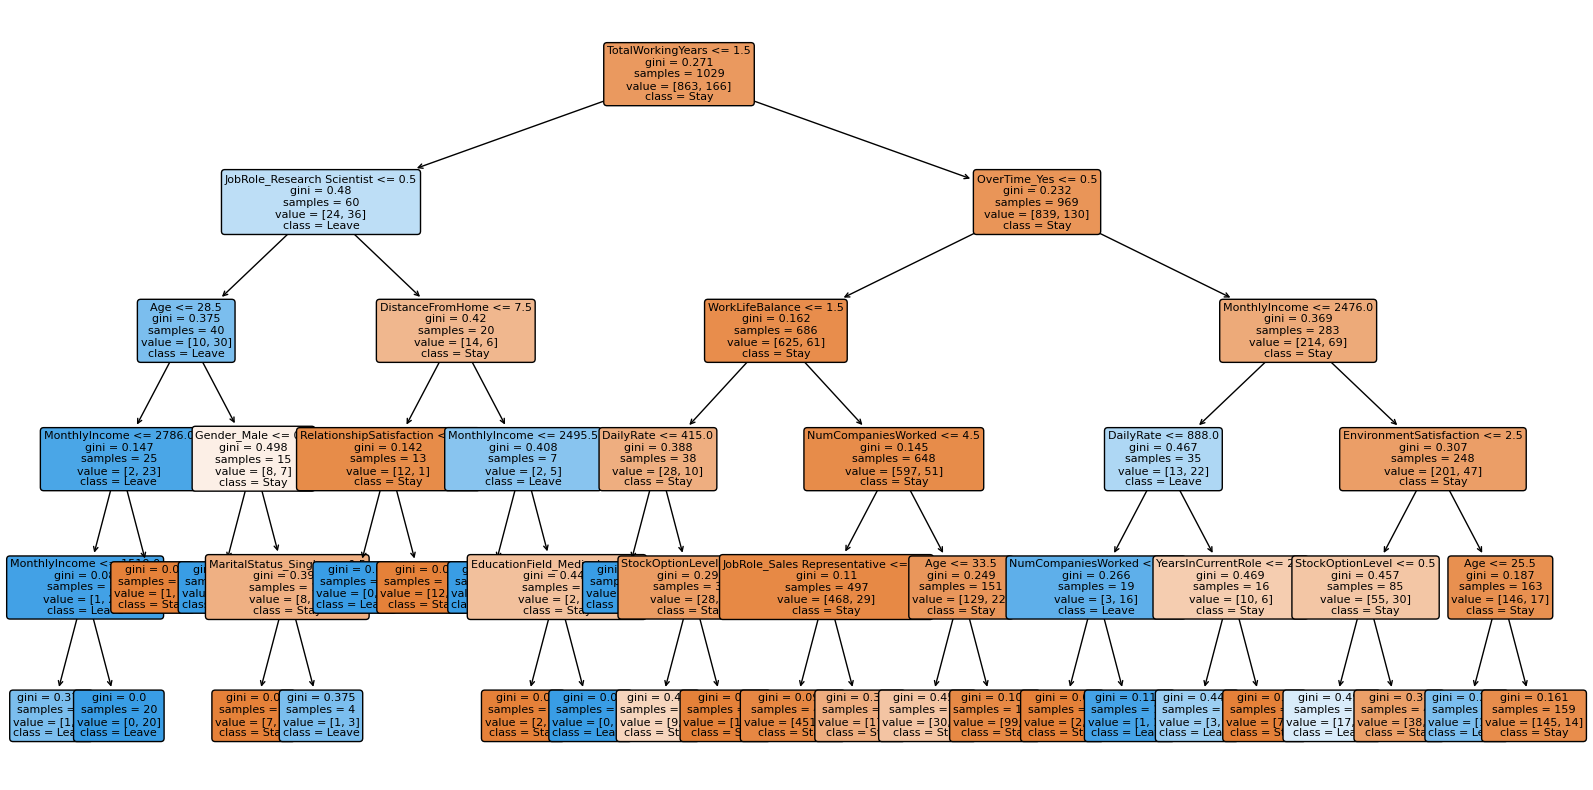

In [7]:
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=['Stay','Leave'], 
          filled=True, rounded=True, fontsize=8)
plt.show()



Top 10 Important Features:
TotalWorkingYears: 0.2093
MonthlyIncome: 0.1325
Age: 0.1082
OverTime_Yes: 0.0821
DailyRate: 0.0738
StockOptionLevel: 0.0697
EnvironmentSatisfaction: 0.0590
JobRole_Research Scientist: 0.0461
NumCompaniesWorked: 0.0421
DistanceFromHome: 0.0316


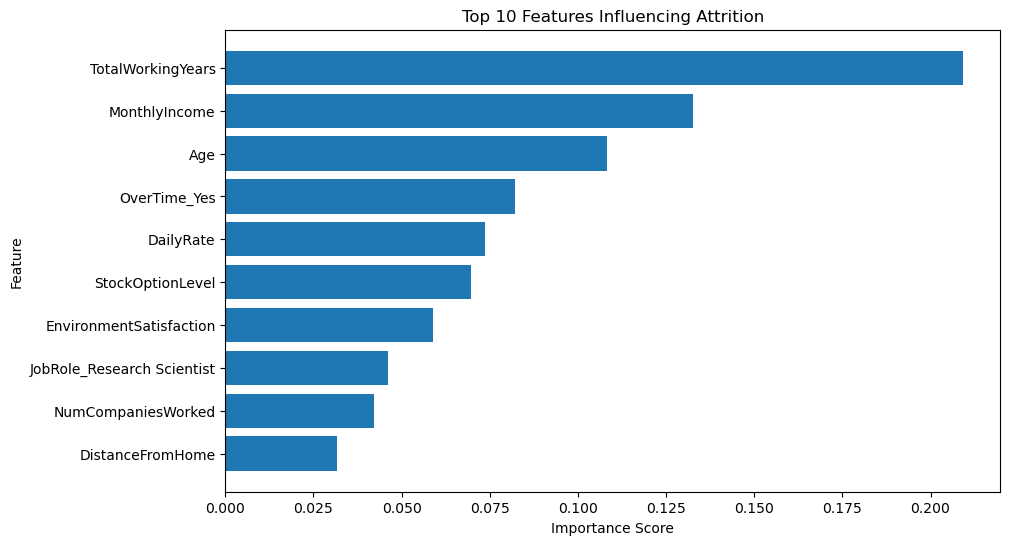

In [8]:
importances = dt.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nTop 10 Important Features:")
for i in indices[:10]:
    print(f"{X.columns[i]}: {importances[i]:.4f}")

# Bar plot
plt.figure(figsize=(10,6))
plt.barh(X.columns[indices[:10]], importances[indices[:10]])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Attrition")
plt.gca().invert_yaxis()
plt.show()


In [9]:
#Accuracy of Decision Tree on employee attrition prediction.

#Confusion matrix (Stay vs Leave predictions).

#Classification report (precision, recall, F1-score).

#Tree visualization showing decision splits (e.g., “If OverTime = Yes & YearsAtCompany < 3 → Leave”).

#Feature importance ranking (you’ll see features like OverTime, JobSatisfaction, Age, MonthlyIncome, YearsAtCompany usually play big roles).